<a href="https://colab.research.google.com/github/AlewaIvanovi4/Educational_projects_Data_Analyst_course/blob/AB-test/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0_5_%D0%A1%D0%BF%D0%BB%D0%B8%D1%82%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5%2C_%D0%9C%D0%BE%D0%BD%D1%82%D0%B5_%D0%9A%D0%B0%D1%80%D0%BB%D0%BE_%D0%B8_Bootstrap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

# import warnings
# warnings.filterwarnings('ignore')

from scipy.stats import ttest_ind
from scipy.stats import kstest
import hashlib
from tqdm import tqdm
from statsmodels.stats.power import tt_ind_solve_power


### Utils

In [ ]:
# ссылка на данные: https://drive.google.com/file/d/1g3HH_6UAcOJxle_GhaRMBTKaj5N0o93e/view?usp=sharing

df = pd.read_csv('sample_data/lesson_5_user_churn.csv')
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4163,0906-QVPMS,Male,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),115.15,8349.45,0
515,3482-ABPKK,Female,0,No,No,28,Yes,No,DSL,Yes,...,No,Yes,No,No,One year,No,Mailed check,54.30,1546.30,0
3437,5996-NRVXR,Male,1,Yes,No,40,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,No,One year,Yes,Credit card (automatic),98.15,4116.80,0
2349,9424-CMPOG,Male,0,Yes,Yes,9,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.60,197.40,0
317,2321-OMBXY,Female,0,Yes,Yes,38,Yes,No,DSL,Yes,...,No,Yes,Yes,Yes,One year,No,Credit card (automatic),80.30,3058.65,1


In [ ]:
df.shape

(7032, 21)

In [ ]:
df['Churn'].mean()

np.float64(0.26578498293515357)

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# функция сплитования пользователей на 2 группы
def simple_splitter(data, user_id_col, config, salt):
    """Возвращает тот же датафрейм  но с колонкой группы"""
    config = {j: i for i, j in config.items()}
    a = config['control'][1] - config['control'][0]
    b = config['test'][1] - config['test'][0]
    percent_data_size = int((a + b) / 100 * len(data))
    data = data.sample(percent_data_size)

    data['group'] = np.random.choice(['control', 'test'], size=len(data))
    return data


def single_split(config, clientid, salt):
    str2hash = str(clientid) + str(salt)
    # print(str2hash)

    # MD5
    result = hashlib.md5(str2hash.encode()) #sha256
    # print(result.hexdigest())

    # HEX to INT
    big_int = int(result.hexdigest(), 16)
    # print(big_int)

    # Remainder
    group = big_int % 100
    # print(group)

    for vals in config.keys():
        if (vals[0] <= group) and (group <= vals[1]):
            return config[vals], str2hash, result.hexdigest(), group

    return 'ERROR', 'error', 'ErRoR', 101


def my_splitter(data, user_id_col, config, salt):
    data['group'] = data.apply(lambda x: single_split(config, x[user_id_col], salt)[0], axis=1)
    return data

In [ ]:
config = {
    (0,49): 'control',
    (50,99): 'test'
}
salt = '3st iteration'
df_new = df.copy()

# main
df_new['group'] = df.apply(lambda x: single_split(config,x['customerID'], salt)[0], axis=1)   # [0], axis=1)
df_new.sample(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,group
13,0280-XJGEX,Male,0,No,No,49,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1,test
3904,0991-BRRFB,Male,0,No,No,18,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,No,Electronic check,49.40,874.8,1,control
6099,4819-HJPIW,Male,0,No,No,18,No,No phone service,DSL,No,...,No,No,No,Month-to-month,No,Mailed check,25.15,476.8,0,control


In [ ]:
def sim_AA(
        hist_data,
        user_id_col,
        metric_col,
        splitter=simple_splitter,
        n_iter=10**3,
        _test=ttest_ind,
        config={},
):
    # AA-симуляции
    lst_p_vals = []
    for salt in tqdm(range(n_iter)):

        data = splitter(hist_data, user_id_col, config, f'{salt}')

        is_control = (data['group'] == 'control')
        group_A1 = data.loc[is_control, metric_col].values
        group_A2 = data.loc[~is_control, metric_col].values

        test_statistic, p_val = _test(group_A1, group_A2)
        lst_p_vals.append(p_val)

    ks_statistic, p_value = kstest(lst_p_vals, 'uniform')
    print(f"KS-test | P-value: {p_value}")

    return np.array(lst_p_vals)


100%|██████████| 100/100 [00:07<00:00, 14.17it/s]


KS-test | P-value: 0.5063281803744706


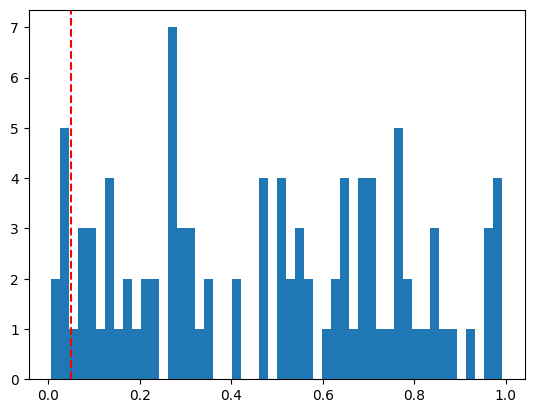

In [ ]:
df_temp = df.copy()
p_vals = sim_AA(
    df_temp,
    'customerID',
    'Churn',
    n_iter=100,
    splitter=my_splitter,
    config = {
        (0,49): 'control',
        (50,99): 'test'
    },
)
plt.hist(p_vals, bins=50)
plt.axvline(0.05, color='r', linestyle='--')
plt.show()

In [ ]:
def sim_AB(
    hist_data,
    user_id_col,
    metric_col,
    splitter=simple_splitter,
    size=3000,
    n_iter=10**3,
    _test=ttest_ind,
    config={},
    effect = 0.1 # относительный эффект (relative MDE)
):
    # Для расчёта размера выборки
    # control_mean = hist_data[metric_col].mean()
    # treat_mean = hist_data[metric_col].mean() * (1 + effect)
    # control_std = hist_data[metric_col].std()

    # cohen_d = (treat_mean - control_mean) / control_std

    # n = tt_ind_solve_power(
    #     effect_size=cohen_d,
    #     alpha=0.05,
    #     power=0.8,
    #     ratio=1,    # n2/n1 - отношение размеров выборки (ni - размер выборки в i-й группе); нужно для дисбалансных выборок
    #     alternative="two-sided"
    # )

    # # print(f"Размер выборки для достижения power=0.8 (для каждой группы): {round(n)}")
    # # print(f"Мы передали в функцию (для каждой группы): {round(size)}")


    # AB-симуляции
    lst_p_vals = []
    for salt in tqdm(range(n_iter)):

        data = splitter(hist_data, user_id_col, config, f'{salt+size*1000}')

        is_control = (data['group'] == 'control')
        group_A = data.loc[is_control, metric_col].values
        group_B = data.loc[~is_control, metric_col].values * (1 + effect)

        test_statistic, p_val = _test(group_A, group_B)
        lst_p_vals.append(p_val)

    return np.array(lst_p_vals)



100%|██████████| 1000/1000 [00:09<00:00, 110.16it/s]


Power: 0.655


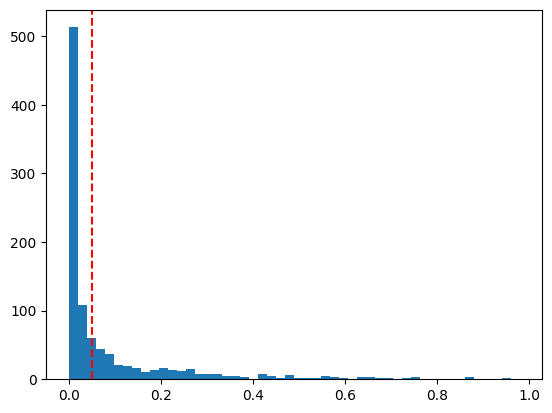

In [ ]:
df_temp = df.copy()
p_vals = sim_AB(
    df_temp,
    'customerID',
    'Churn',
    size=3000,
    n_iter=1000,
    splitter=simple_splitter,
    config = {
        (0,50): 'control',
        (51, 99): 'test'
    },
    effect = 0.1
)

print(f"Power: {(p_vals < 0.05).mean()}")
plt.hist(p_vals, bins=50)
plt.axvline(0.05, color='r', linestyle='--')
plt.show()

In [ ]:
# функция расчета размера выборки
def sample_size_calc(
        hist_data,
        user_id_col,
        metric_col,
        splitter=simple_splitter,
        n_iter=10**3,
        _test=ttest_ind,
        config={},
        effect = 0.1, # относительный эффект (relative MDE)
        start_sample_size = 100,
        step_size = 50,
        power_threshold = 0.8,
        plot = True
):
    power_lst = []
    sample_sie_lst = []
    for smpl_size in range(start_sample_size, len(hist_data), step_size):
        split_point = int(smpl_size / len(hist_data) * 100)

        p_vals = sim_AB(
            hist_data,
            user_id_col,
            metric_col,
            splitter,
            smpl_size,
            n_iter,
            _test,
            {
              (0,int(split_point / 2)): 'control',
              (int(split_point / 2), split_point): 'test'
            },
            effect, # относительный эффект (relative MDE)
        )
        power = (p_vals < 0.05).mean()
        print(f"power: {power}, split_point: {split_point}, smpl_size: {smpl_size}")
        power_lst.append(power)
        sample_sie_lst.append(smpl_size)

        if smpl_size % 1000 == 0:
            print(smpl_size)

        if power > power_threshold:
            print(f"Sample size for power={power_threshold}: {smpl_size}")
            break

    if plot:
        plt.plot(sample_sie_lst, power_lst)
        plt.axhline(y=power_threshold, color='r', linestyle='--')
        plt.xlabel("Sample size")
        plt.ylabel("Power")
        plt.title("Sample size calculation")



100%|██████████| 500/500 [00:03<00:00, 125.15it/s]


power: 0.066, split_point: 1, smpl_size: 100


100%|██████████| 500/500 [00:01<00:00, 250.62it/s]


power: 0.066, split_point: 2, smpl_size: 200


100%|██████████| 500/500 [00:02<00:00, 232.41it/s]


...

power: 0.77, split_point: 69, smpl_size: 4900


100%|██████████| 500/500 [00:03<00:00, 142.90it/s]


power: 0.8, split_point: 71, smpl_size: 5000
5000


100%|██████████| 500/500 [00:04<00:00, 112.86it/s]


power: 0.814, split_point: 72, smpl_size: 5100
Sample size for power=0.8: 5100


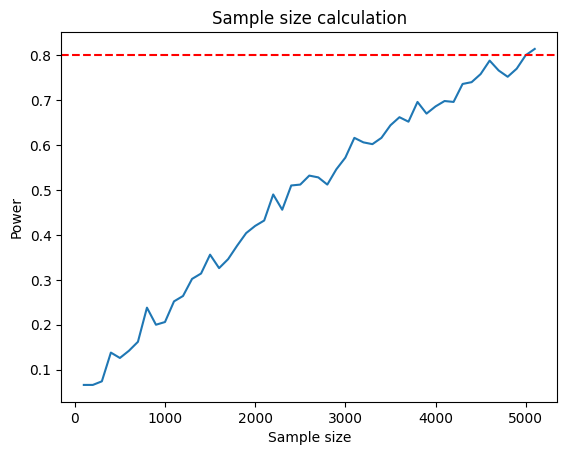

In [ ]:
df_temp = df.copy()
p_vals = sample_size_calc(
    df_temp,
    'customerID',
    'Churn',
    n_iter=500,
    splitter=simple_splitter,
    config = {
        (0,49): 'control',
        (50,99): 'test'
    },
    effect = 0.14,

    start_sample_size = 100,
    step_size = 100,
    power_threshold = 0.8,
    plot = True

)

In [ ]:
Т# @title Default title text
# функция тестирования гипотез через bootstrap
def bootstrap_test_v1(sample1, sample2, func=np.mean, B=10**3, alpha=0.05):
    """Реализация через цикл"""

    diff = []
    for i in range(B):

        a_elem = np.random.choice(sample1, size=len(sample1), replace=True)
        b_elem = np.random.choice(sample2, size=len(sample2), replace=True)

        diff.append(func(a_elem) - func(b_elem))

    left_bound = np.quantile(diff, alpha / 2)
    right_bound = np.quantile(diff, 1 - alpha / 2)

    decision = 1 if left_bound > 0 or right_bound < 0 else 0

    return decision, (diff, left_bound, right_bound)


def bootstrap_test_v2(sample1, sample2, func=np.mean, B=10**3, alpha=0.05):
    """
    Векторизироанния реализация
    Возвращает 1 если результат стат. значимый, иначе 0
    """

    a_bootstrap = np.random.choice(sample1, size=(len(sample1), B))
	  b_bootstrap = np.random.choice(sample2, size=(len(sample2), B))

	  diff = func(b_bootstrap, axis=0) - func(a_bootstrap, axis=0)

    left_bound = np.quantile(diff, alpha / 2)
    right_bound = np.quantile(diff, 1 - alpha / 2)

    decision = 1 if left_bound > 0 or right_bound < 0 else 0

    return decision, (diff, left_bound, right_bound)


In [ ]:
def plot_bootstrap_summary(diff, left_bound, right_bound, plot_zero=False):
    sns.histplot(diff, kde=True, bins=50)
    plt.axvline(x=left_bound, color='red', ls='--')
    plt.axvline(x=right_bound, color='red', ls='--')
    if plot_zero:
        plt.axvline(x=0, color='blue', ls='-')

    plt.title('Bootstrap test')
    plt.show()

Пример симуляция размера выборки с помощью Bootsrap (когда размера выборки исторических данных недостаточно):

https://github.com/popkins162/bootstrap_duration/blob/main/Sample_size_bootstrap.ipynb